# CSCAS baseline comparison

Compares twelve baselines evaluated on the identical CSCAS train/test split and training-pool protocol (see `baselines/cscas.py`, `baselines/cscas_base.py`, `baselines/cscas_mining.py`, `baselines/cscas_logreg.py`, `baselines/cscas_xgboost.py`, `baselines/cscas_bert.py`, `baselines/cscas_securebert.py`, `baselines/cscas_zeroshot.py`, `baselines/cscas_anomaly.py`, `baselines/cscas_anomaly_iforest.py`, `baselines/cscas_mining_anomaly.py`, `baselines/cscas_mining_anomaly_iforest.py`):

1. **Paper** -- the CSCAS paper's own 42 raw features, `RandomForestClassifier`
2. **Base schema (RF)** -- this project's 5-feature reduced `base` schema (paper's features minus `SignatureID`, `SCAS`, and every `*Similarity` column -- none of those are things a real deployment could compute for a fresh alert without already knowing the answer or running CSCAS's offline similarity pipeline), `RandomForestClassifier`
3. **Base schema + Mining (RF)** -- the same 5-feature base schema extended with symbolic features mined by the attribute-mining pipeline (contrast-set + decision-tree rules) on the identical train split, `RandomForestClassifier`. Mining excludes the same SCAS/Similarity-derived fields as the base schema, for the same realism reason.
4. **Base schema (LogReg)** -- same reduced base schema, `LogisticRegression` (`StandardScaler` + missingness flags for the `-1` sentinel columns)
5. **Base schema (XGBoost)** -- same reduced base schema, `XGBClassifier`
6. **BERT** -- same 6 reduced fields (no `SignatureID`/`SCAS`/`Similarity`) serialized to text, fine-tuned DistilBERT
7. **SecureBERT** -- same 6 fields, fine-tuned SecureBERT 2.0 (ModernBERT architecture, domain-adapted)
8. **Zero-shot** -- same 6 fields serialized to a prompt, Llama-3.1-8B-Instruct, no fine-tuning
9. **Anomaly (OneClassSVM)** -- same reduced base schema, `OneClassSVM` fit on benign-only train rows (no attack examples used in training at all) -- see the "Anomaly baseline" section below for why this one exists alongside the other classifiers.
10. **Anomaly (IsolationForest)** -- same reduced base schema, benign-only fit, second anomaly-detector model family alongside method 9 -- isolates model choice within the anomaly-detector family the same way LogReg/XGBoost do within the classifier family, rather than treating "the anomaly baseline" as a single fixed model. Tree-based, so unlike OneClassSVM it needs no feature scaling.
11. **Anomaly + Mining (OneClassSVM)** -- method 3's mined symbolic features, on top of the reduced base schema, `OneClassSVM` fit on benign-only train rows -- the mining sibling of method 9, the most complete "system" scenario (mining + task, one-class) evaluated here. Mining still runs on the full train split (both classes, mining needs the attack rows to find informative contrast predicates) -- only the classifier fit itself is benign-only.
12. **Anomaly + Mining (IsolationForest)** -- method 11's mined symbolic features on the reduced base schema, but `IsolationForest` fit on benign-only train rows instead of `OneClassSVM`. Stands to method 11 as method 10 stands to method 9: isolates the anomaly-detector model choice within the mining scenario. Same benign-only fit, same shared mined predicates as method 11 (cache-shared), tree-based so no feature scaling.

The first seven (paper, base RF, base + mining, LogReg, XGBoost, BERT, SecureBERT) all report all **three training-pool conditions**: random undersampling, class-weighted/natural-ratio, and guided by CSCAS's SCAS outlier clusters. All trainable methods evaluate on the same shared eval subsample (the paper-replication script is the one exception, staying on the full test set to match the published protocol). Zero-shot and all four anomaly methods have no training-pool step, so none of them report the three conditions -- each reports a single flat run against the shared eval subsample (zero-shot: precision/recall/f1; anomaly: auc/precision/recall/f1).

**Anomaly baselines.** AIT-ADS has 3 scenarios (`harrison`, `santos`, `russellmitchell` -- see `ait_ads_baseline_comparison.ipynb`) where every attack-labelled alert_group falls in the test split, so a *classifier* baseline's train split ends up 100% benign and gets skipped entirely. All four anomaly baselines are a general workaround for that failure mode: they only ever need benign rows to train, so none is blocked by a single-class train split (mining itself still needs attack rows to find contrast predicates -- for a 100%-benign train split, `cscas_mining_anomaly.py`'s AIT-ADS counterpart falls back to 0 mined predicates, not a crash, so it still produces a result there, just without added symbolic signal). CSCAS's own split doesn't happen to hit this problem (train already has 1,765 positive rows), so `cscas_anomaly.py`, `cscas_anomaly_iforest.py`, `cscas_mining_anomaly.py`, and `cscas_mining_anomaly_iforest.py` are included here mainly for a fair method-for-method comparison against the AIT-ADS side, not because CSCAS needed the workaround itself.

**Run the scripts first** to generate the `results/*.json` files this notebook reads:
```
cd src/thesis/baselines
python cscas.py
python cscas_base.py
python cscas_mining.py
python cscas_logreg.py
python cscas_xgboost.py
python cscas_bert.py
python cscas_securebert.py
python cscas_zeroshot.py
python cscas_anomaly.py
python cscas_anomaly_iforest.py
python cscas_mining_anomaly.py
python cscas_mining_anomaly_iforest.py
```

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from thesis.baselines._results import RESULTS_DIR, is_anomaly, is_zero_shot, load_baseline_results

## Settings

Edit and re-run -- nothing past this cell needs to change.

In [2]:
RESULT_NAMES = [
    "cscas",
    "cscas_base",
    "cscas_mining",
    "cscas_logreg",
    "cscas_xgboost",
    "cscas_bert",
    "cscas_securebert",
    "cscas_zeroshot",
    "cscas_anomaly_ocsvm",
    "cscas_anomaly_iforest",
    "cscas_mining_anomaly_ocsvm",
    "cscas_mining_anomaly_iforest",
]

LABELS = {
    "cscas": "Paper (42 features, RF)",
    "cscas_base": "Base schema (RF)",
    "cscas_mining": "Base schema + Mining (RF)",
    "cscas_logreg": "Base schema (LogReg)",
    "cscas_xgboost": "Base schema (XGBoost)",
    "cscas_bert": "BERT (6 fields as text)",
    "cscas_securebert": "SecureBERT 2.0 (6 fields as text)",
    "cscas_zeroshot": "Zero-shot (Llama-3.1-8B-Instruct)",
    "cscas_anomaly_ocsvm": "Anomaly (OneClassSVM, benign-only)",
    "cscas_anomaly_iforest": "Anomaly (IsolationForest, benign-only)",
    "cscas_mining_anomaly_ocsvm": "Anomaly + Mining (OneClassSVM, benign-only)",
    "cscas_mining_anomaly_iforest": "Anomaly + Mining (IsolationForest, benign-only)",
}

COLORS = {
    "cscas": "#4477AA",
    "cscas_base": "#CCBB44",
    "cscas_mining": "#EE8866",
    "cscas_logreg": "#228833",
    "cscas_xgboost": "#66CCEE",
    "cscas_bert": "#EE6677",
    "cscas_securebert": "#AA3377",
    "cscas_zeroshot": "#BBBBBB",
    "cscas_anomaly_ocsvm": "#44BB99",
    "cscas_anomaly_iforest": "#117733",
    "cscas_mining_anomaly_ocsvm": "#DDCC77",
    "cscas_mining_anomaly_iforest": "#999933",
}

# Where this notebook's own outputs go -- separate from the *.json the
# baseline scripts write, but alongside them: figures/ subdir for plots,
# summary CSV directly in RESULTS_DIR.
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
results = {}
for name in RESULT_NAMES:
    try:
        results[name] = load_baseline_results(name)
    except FileNotFoundError as e:
        print(f"[skip] {e}")

print(f"Loaded results for: {list(results.keys())}")

Loaded results for: ['cscas', 'cscas_base', 'cscas_mining', 'cscas_logreg', 'cscas_xgboost', 'cscas_bert', 'cscas_securebert', 'cscas_zeroshot', 'cscas_anomaly_ocsvm', 'cscas_anomaly_iforest', 'cscas_mining_anomaly_ocsvm', 'cscas_mining_anomaly_iforest']


In [4]:
def plot_baseline(condition_key: str, title: str) -> None:
    """Grouped bar chart across every loaded method that actually reports
    `condition_key` -- excludes zero-shot and anomaly always (both flat
    shape, no conditions -- see plot_zeroshot()/plot_anomaly() below).
    Error bars are the sample std (ddof=1) across the 5 training seeds.
    Every trainable method now reports all three conditions, so this
    naturally includes everything that's loaded. Saves to
    FIGURES_DIR/{condition_key}.png before displaying."""
    metrics = ["precision", "recall", "f1"]
    methods = [
        n for n in RESULT_NAMES
        if n in results and not is_zero_shot(results[n]) and not is_anomaly(results[n])
        and condition_key in results[n]
    ]
    if not methods:
        print(f"No results loaded with a '{condition_key}' condition -- run the baseline scripts first.")
        return

    x = np.arange(len(metrics))
    width = 0.85 / len(methods)

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, name in enumerate(methods):
        cond = results[name][condition_key]
        values = [cond[m] for m in metrics]
        seeds = cond.get("seeds") or []
        errs = [
            float(np.std([s[m] for s in seeds], ddof=1)) if len(seeds) > 1 else 0.0
            for m in metrics
        ]
        offset = (i - (len(methods) - 1) / 2) * width
        bars = ax.bar(
            x + offset, values, width,
            yerr=errs, capsize=2, error_kw={"lw": 0.8},
            label=LABELS.get(name, name), color=COLORS.get(name),
        )
        ax.bar_label(bars, fmt="%.2f", fontsize=7, padding=2, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels([m.capitalize() for m in metrics])
    ax.set_ylim(0, 1.2)
    ax.set_ylabel("Score")
    ax.set_title(f"{title}  (error bars: seed std, n=5)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    save_path = FIGURES_DIR / f"{condition_key}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Figure written to {save_path}")

    plt.show()

## Random undersampling

Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/random.png


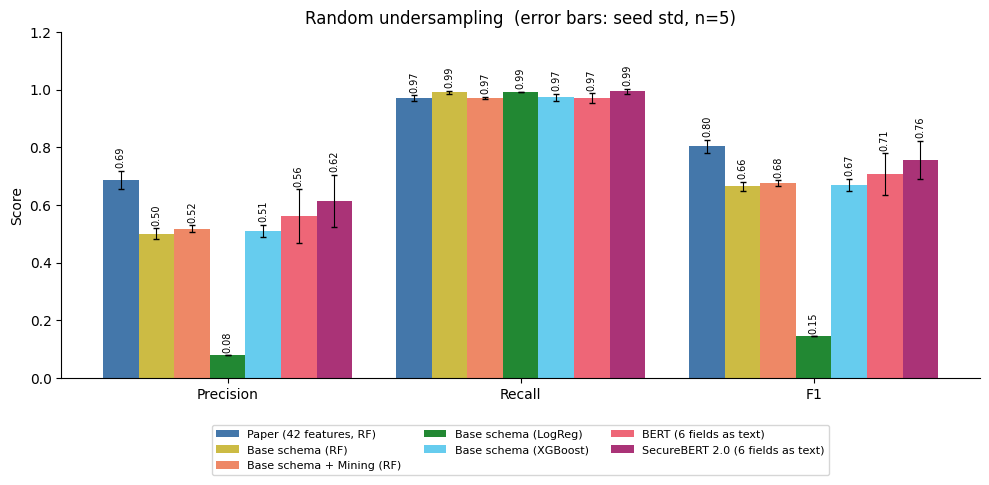

In [5]:
plot_baseline("random", "Random undersampling")

## Class-weighted (natural-ratio)

Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/class_weighted.png


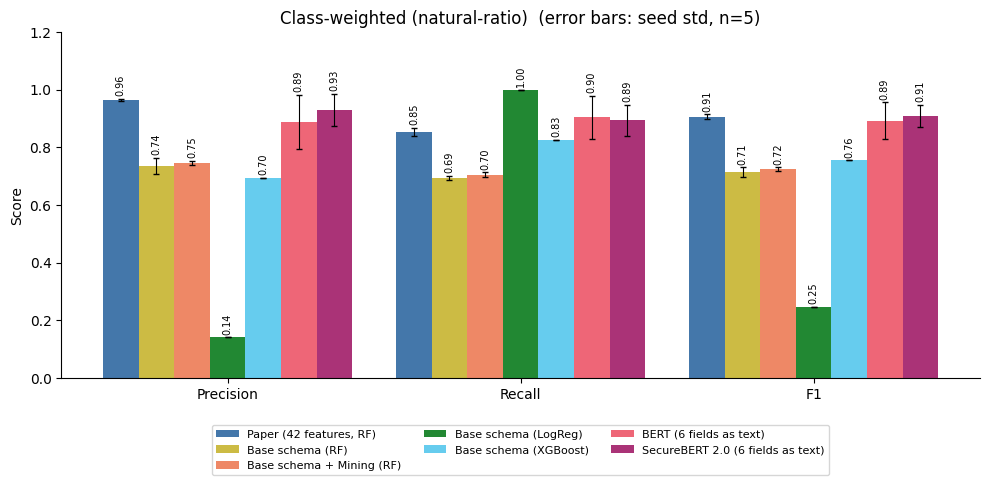

In [6]:
plot_baseline("class_weighted", "Class-weighted (natural-ratio)")

## Guided by CSCAS

Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/guided.png


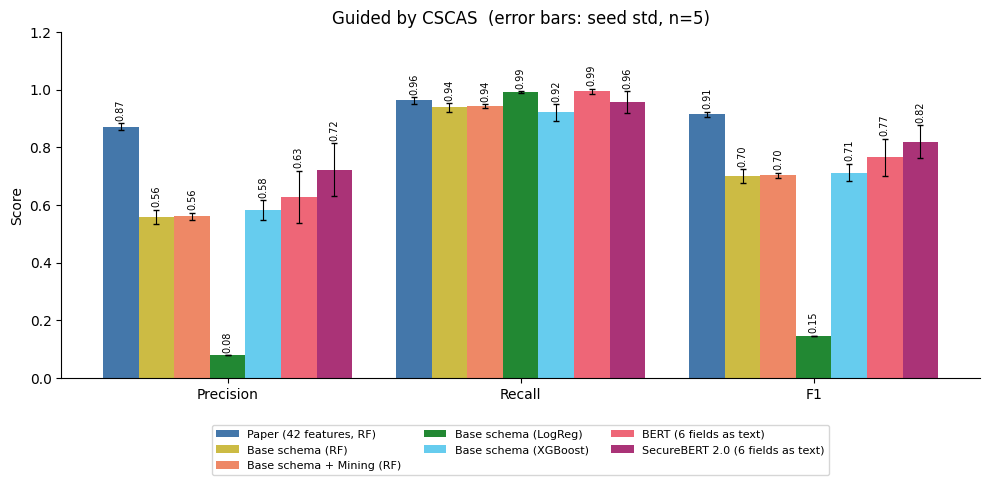

In [7]:
plot_baseline("guided", "Guided by CSCAS")

## Zero-shot

The one method without the three-condition structure (no training pool, no seeds) -- a single bar per metric from one deterministic run, not comparable to `plot_baseline()`'s per-condition grouped bars above.

Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/zeroshot.png


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_23004/2143097590.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.capitalize() for m in metrics])


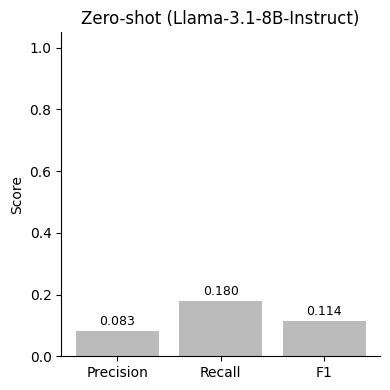

In [8]:
def plot_zeroshot() -> None:
    name = "cscas_zeroshot"
    if name not in results or not is_zero_shot(results[name]):
        print("No zero-shot results loaded -- run cscas_zeroshot.py first.")
        return

    metrics = ["precision", "recall", "f1"]
    data = results[name]
    values = [data[m] for m in metrics]

    fig, ax = plt.subplots(figsize=(4, 4))
    bars = ax.bar(metrics, values, color=COLORS.get(name))
    ax.bar_label(bars, fmt="%.3f", fontsize=9, padding=2)

    ax.set_xticklabels([m.capitalize() for m in metrics])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(LABELS.get(name, name))
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    save_path = FIGURES_DIR / "zeroshot.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Figure written to {save_path}")

    plt.show()


plot_zeroshot()

## Anomaly (OneClassSVM, benign-only)

No training pool, no undersampling -- fit on benign rows only. OneClassSVM(kernel='rbf', nu=0.05) is a deterministic convex fit (no random_state), so this is a genuine single run; its IsolationForest siblings below are 5-seeded. Each reports `auc` alongside precision/recall/f1 (its headline metric, since scoring is threshold-free); not comparable to `plot_baseline()`'s per-condition grouped bars above.

Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/anomaly.png


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_23004/3182817584.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.upper() if m == "auc" else m.capitalize() for m in metrics])


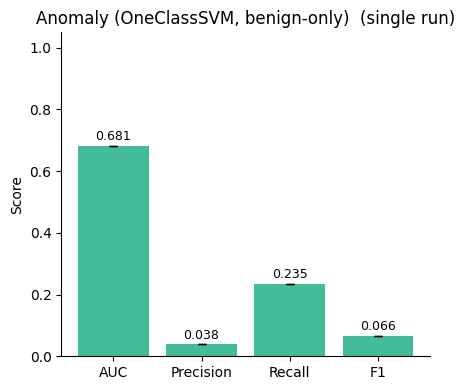

In [9]:
def plot_anomaly(name: str, save_name: str) -> None:
    if name not in results or not is_anomaly(results[name]):
        print(f"No anomaly results loaded for '{name}' -- run the matching script first.")
        return

    metrics = ["auc", "precision", "recall", "f1"]
    data = results[name]
    values = [data[m] for m in metrics]
    seeds = data.get("seeds") or []
    errs = [
        float(np.std([s[m] for s in seeds], ddof=1)) if len(seeds) > 1 else 0.0
        for m in metrics
    ]

    fig, ax = plt.subplots(figsize=(4.5, 4))
    bars = ax.bar(metrics, values, color=COLORS.get(name),
                  yerr=errs, capsize=3, error_kw={"lw": 0.8})
    ax.bar_label(bars, fmt="%.3f", fontsize=9, padding=2)

    ax.set_xticklabels([m.upper() if m == "auc" else m.capitalize() for m in metrics])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    n = len(seeds)
    ax.set_title(LABELS.get(name, name) + (f"  (error bars: seed std, n={n})" if n > 1 else "  (single run)"))
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    save_path = FIGURES_DIR / f"{save_name}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Figure written to {save_path}")

    plt.show()


plot_anomaly("cscas_anomaly_ocsvm", "anomaly")

## Anomaly (IsolationForest, benign-only)

Second anomaly-detector model family alongside the OneClassSVM above -- same benign-only fit, same reduced base schema, tree-based so no feature scaling. Tree bootstrapping is stochastic, so this runs the same 5-seed protocol (`random_state=0..4`) the trainable baselines use; error bars are the seed std.

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_23004/3182817584.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.upper() if m == "auc" else m.capitalize() for m in metrics])


Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/anomaly_iforest.png


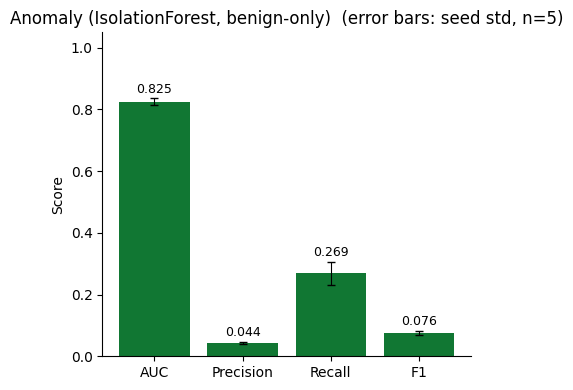

In [10]:
plot_anomaly("cscas_anomaly_iforest", "anomaly_iforest")

## Anomaly + Mining (OneClassSVM, benign-only)

Method 3's mined symbolic features on top of the reduced base schema, same benign-only `OneClassSVM` fit as the plain anomaly baseline above (single deterministic run).

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_23004/3182817584.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.upper() if m == "auc" else m.capitalize() for m in metrics])


Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/mining_anomaly.png


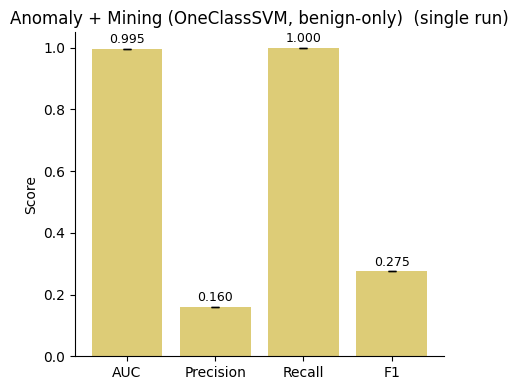

In [11]:
plot_anomaly("cscas_mining_anomaly_ocsvm", "mining_anomaly")

## Anomaly + Mining (IsolationForest, benign-only)

Method 3's mined symbolic features on top of the reduced base schema, fit as a benign-only `IsolationForest` instead of the `OneClassSVM` above -- the IsolationForest sibling of the mining anomaly baseline, 5-seeded (`random_state=0..4`), same shared mined predicates, tree-based so no feature scaling.

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_23004/3182817584.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.upper() if m == "auc" else m.capitalize() for m in metrics])


Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/mining_anomaly_iforest.png


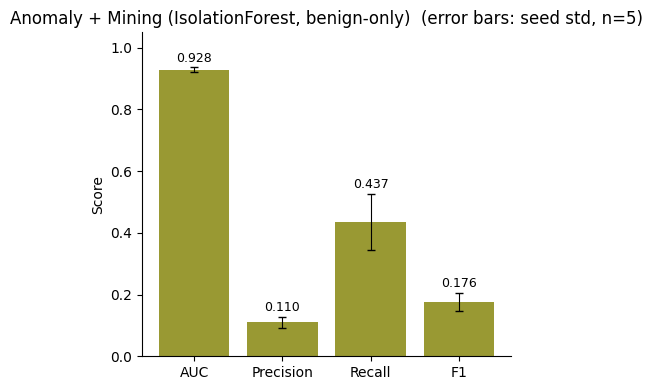

In [12]:
plot_anomaly("cscas_mining_anomaly_iforest", "mining_anomaly_iforest")

## Summary table

Tidy view of all loaded results -- handy to copy straight into a slide.

In [13]:
CONDITION_LABELS = {
    "random": "Random undersampling",
    "class_weighted": "Class-weighted (natural-ratio)",
    "guided": "Guided by CSCAS",
}

rows = []
for name, data in results.items():
    if is_zero_shot(data) or is_anomaly(data):
        rows.append({
            "method": LABELS.get(name, name),
            "condition": "(no training)",
            "auc": data.get("auc"),
            "precision": data["precision"],
            "recall": data["recall"],
            "f1": data["f1"],
        })
    else:
        for condition_key, condition_label in CONDITION_LABELS.items():
            if condition_key not in data:
                continue  # defensive: every trainable method reports all three today
            rows.append({
                "method": LABELS.get(name, name),
                "condition": condition_label,
                "auc": None,
                "precision": data[condition_key]["precision"],
                "recall": data[condition_key]["recall"],
                "f1": data[condition_key]["f1"],
            })

if not rows:
    print("No results loaded -- run the baseline scripts first.")
    summary_df = pd.DataFrame(columns=["method", "condition", "auc", "precision", "recall", "f1"])
else:
    summary_df = pd.DataFrame(rows).sort_values(["condition", "method"]).reset_index(drop=True)
    summary_csv_path = RESULTS_DIR / "cscas_baseline_summary.csv"
    summary_df.to_csv(summary_csv_path, index=False)
    print(f"Summary written to {summary_csv_path}")
summary_df

Summary written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/cscas_baseline_summary.csv


,method,condition,auc,precision,recall,f1
0,"Anomaly (IsolationForest, benign-only)",(no training),0.825275,0.044125,0.269281,0.075714
1,"Anomaly (OneClassSVM, benign-only)",(no training),0.681420,0.038400,0.235294,0.066025
2,"Anomaly + Mining (IsolationForest, benign-only)",(no training),0.928094,0.110319,0.436601,0.176006
3,"Anomaly + Mining (OneClassSVM, benign-only)",(no training),0.995162,0.159624,1.000000,0.275304
4,Zero-shot (Llama-3.1-8B-Instruct),(no training),NaN,0.082956,0.179739,0.113519
5,BERT (6 fields as text),Class-weighted (natural-ratio),NaN,0.888308,0.904575,0.892974
6,Base schema (LogReg),Class-weighted (natural-ratio),NaN,0.140949,1.000000,0.247073
7,Base schema (RF),Class-weighted (natural-ratio),NaN,0.736482,0.693464,0.714170
8,Base schema (XGBoost),Class-weighted (natural-ratio),NaN,0.695055,0.826797,0.755224
9,Base schema + Mining (RF),Class-weighted (natural-ratio),NaN,0.745578,0.704575,0.724457


## LaTeX summary table

One block per baseline, with the configuration knobs that actually vary across
baselines broken out as columns:

| knob | column | values |
|---|---|---|
| input representation | **Features** | `Paper (42)` raw paper features · `Base (5)` reduced tabular schema · `Base (5) + mined` reduced schema plus attribute-mined symbolic features · `Base (6) as text` 6 reduced fields serialized to text/prompt |
| training regime | **Training** | for the trainable classifiers, one row per **sampling condition** (`random` undersampling · `class-weighted` natural-ratio · `guided` by CSCAS's SCAS clusters); `natural ratio` for the paper target, `benign-only` for the one-class anomaly detectors, `none` for the zero-shot LLMs |
| learner | **Model** | RF / LogReg / XGBoost / DistilBERT / SecureBERT / Llama-3.1 (8B, 70B) / Qwen2.5 (7B, 72B) / OneClassSVM / IsolationForest |

**Precision / Recall / F1** are at each model's own decision threshold, shown as
mean$_{\pm\text{sd}}$ over the 5 seeds. Paper target and zero-shot rows are
single runs (no sd); the IsolationForest anomaly rows are 5-seeded like the
classifiers, and the OneClassSVM anomaly rows are a deterministic single fit
shown as $\pm$0.000. The zero-shot block lists four instruction-tuned models run
on the identical prompt.

The paper-reproduced rows are scored on the full test set (published protocol); all
other rows on the shared eval subsample. Writes `results/cscas_baseline_summary.tex`
(the `\resizebox` in the output needs `\usepackage{graphicx}`).

See the cells below for the **mining-vs-base paired test**, the **zero-shot model
sweep**, and the **alert-volume / confusion-count** table.

In [14]:
# Shared eval subsample composition (stratified-proportional, seed 0, n=20,000;
# see baselines/_sampling.get_cscas_eval_subsample). Full test split totals come
# from the assertions in cscas_base.py / cscas.py. Used here and by the
# alert-volume cell below.
EVAL_POS, EVAL_NEG, EVAL_N = 306, 19_694, 20_000
TEST_POS, TEST_NEG, TEST_N = 19_187, 1_236_605, 1_255_792
EVAL_PREVALENCE = EVAL_POS / EVAL_N  # 0.0153

# (section, baseline, model, features, kind, result_key, regime_label)
#   kind "paper_target" -> single row, hardcoded published metrics
#   kind "trainable"    -> one row per sampling condition (random / class_weighted / guided)
#   kind "flat"         -> single row from the top-level metrics (zero-shot / anomaly)
TABLE_SPEC = [
    ("paper",    "Paper (target)",        "Random Forest",          "Paper (42)",       "paper_target", None,                           "natural ratio"),
    ("paper",    "Paper (reproduced)",    "Random Forest",          "Paper (42)",       "trainable",    "cscas",                        None),
    ("internal", "Internal system",       "Logistic Regression",    "Base (5)",         "trainable",    "cscas_logreg",                 None),
    ("internal", "Internal system",       "Random Forest",          "Base (5)",         "trainable",    "cscas_base",                   None),
    ("internal", "Internal system",       "XGBoost",                "Base (5)",         "trainable",    "cscas_xgboost",                None),
    ("mining",   "Internal + mining",     "Random Forest",          "Base (5) + mined", "trainable",    "cscas_mining",                 None),
    ("llm",      "LLM (zero-shot)",       "Llama-3.1-8B-Instruct",  "Base (6) as text", "flat",         "cscas_zeroshot",               "none"),
    ("llm",      "LLM (zero-shot)",       "Llama-3.1-70B-Instruct", "Base (6) as text", "flat",         "cscas_zeroshot_llama3.1-70b",  "none"),
    ("llm",      "LLM (zero-shot)",       "Qwen2.5-7B-Instruct",    "Base (6) as text", "flat",         "cscas_zeroshot_qwen2.5-7b",    "none"),
    ("llm",      "LLM (zero-shot)",       "Qwen2.5-72B-Instruct",   "Base (6) as text", "flat",         "cscas_zeroshot_qwen2.5-72b",   "none"),
    ("llm",      "LLM (general)",         "DistilBERT",             "Base (6) as text", "trainable",    "cscas_bert",                   None),
    ("llm",      "LLM (domain-specific)", "SecureBERT 2.0",         "Base (6) as text", "trainable",    "cscas_securebert",             None),
    ("anom",     "Anomaly",               "OneClassSVM",            "Base (5)",         "flat",         "cscas_anomaly_ocsvm",          "benign-only"),
    ("anom",     "Anomaly",               "IsolationForest",        "Base (5)",         "flat",         "cscas_anomaly_iforest",        "benign-only"),
    ("anom",     "Anomaly + mining",      "OneClassSVM",            "Base (5) + mined", "flat",         "cscas_mining_anomaly_ocsvm",   "benign-only"),
    ("anom",     "Anomaly + mining",      "IsolationForest",        "Base (5) + mined", "flat",         "cscas_mining_anomaly_iforest", "benign-only"),
]

TRAIN_CONDITIONS = [
    ("random", "random"),
    ("class_weighted", "class-weighted"),
    ("guided", "guided"),
]

# Published CSCAS paper headline numbers (the replication target).
PAPER_TARGET = {"precision": 0.868, "recall": 0.952, "f1": 0.908}


def _result(key: str) -> dict | None:
    """results[key] if loaded, else load on demand (the zero-shot model
    sweep keys aren't in RESULT_NAMES), else None if the script hasn't run."""
    if key in results:
        return results[key]
    try:
        return load_baseline_results(key)
    except FileNotFoundError:
        return None


def _pick(src: dict | None) -> dict | None:
    if src is None:
        return None
    out = {m: src.get(m) for m in ("precision", "recall", "f1")}
    seeds = src.get("seeds") or []
    # anomaly rows without a seed list are the OneClassSVM detectors -- a
    # deterministic convex fit, so their run-to-run sd is genuinely 0.000
    # (shown as +/- 0.000); the paper target / zero-shot rows just have no sd.
    zero_sd = src.get("kind") == "anomaly"
    for m in ("precision", "recall", "f1"):
        vals = [s[m] for s in seeds]
        if len(vals) > 1:
            out[f"{m}_sd"] = float(np.std(vals, ddof=1))
        else:
            out[f"{m}_sd"] = 0.0 if zero_sd else None
    return out


table_rows = []
for gid, (section, baseline, model, features, kind, key, regime) in enumerate(TABLE_SPEC):
    if kind == "paper_target":
        entries = [(regime, _pick(PAPER_TARGET))]
    elif kind == "flat":
        entries = [(regime, _pick(_result(key)))]
    else:  # trainable -- one entry per sampling condition
        data = _result(key)
        entries = [
            (label, _pick(data.get(cond) if data else None))
            for cond, label in TRAIN_CONDITIONS
        ]
    for training_label, m in entries:
        row = {"gid": gid, "section": section, "Baseline": baseline,
               "Model": model, "Features": features, "Training": training_label}
        for col in ("Precision", "Recall", "F1"):
            row[col] = None if m is None else m[col.lower()]
            row[f"{col}_sd"] = None if m is None else m.get(f"{col.lower()}_sd")
        table_rows.append(row)

table_df = pd.DataFrame(table_rows).drop(columns=["gid", "section"]).round(4)

# --- emit LaTeX (repeated Baseline/Model/Features blanked within a block) ---
def _cell(v, sd=None) -> str:
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return ""
    if sd is None or pd.isna(sd):
        return f"{v:.3f}"
    return f"${v:.3f}_{{\\pm {sd:.3f}}}$"

tex_lines = []
prev_section = prev_gid = None
for row in table_rows:
    if prev_section is not None and row["section"] != prev_section:
        tex_lines.append(r"\midrule")
    elif prev_gid is not None and row["gid"] != prev_gid:
        tex_lines.append(r"\addlinespace")
    first = row["gid"] != prev_gid
    prev_section, prev_gid = row["section"], row["gid"]
    b = row["Baseline"] if first else ""
    mo = row["Model"] if first else ""
    fe = row["Features"] if first else ""
    tex_lines.append(
        f"{b} & {mo} & {fe} & {row['Training']} & "
        f"{_cell(row['Precision'], row['Precision_sd'])} & "
        f"{_cell(row['Recall'], row['Recall_sd'])} & "
        f"{_cell(row['F1'], row['F1_sd'])}" + r" \\"
    )

latex = (
    r"""\begin{table}[htbp]
\centering
\small
\caption{Summary of baseline performance on the CSCAS test set. Trainable
classifiers report all three training-pool sampling conditions (random
undersampling, class-weighted natural-ratio, guided by CSCAS's SCAS clusters) as
mean$_{\pm\text{sd}}$ over 5 seeds; the paper target is the published result, the
anomaly detectors are fit on benign rows only, and the zero-shot LLMs have no
training step. Precision/recall/F1 are at each model's own decision threshold; the
guided condition systematically trades precision for recall across every
classifier. The paper-reproduced rows are scored on the full test set to match the
published protocol; all other rows use the shared eval subsample. The anomaly rows are at the detectors' default rejection rate (nu / contamination = 0.05), which over-flags relative to the 1.5\% attack prevalence; Table~\ref{tab:cscas-anomaly-operating-points} reports them at a tuned threshold.}
\label{tab:cscas-baseline-summary}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llllccc}
\toprule
\textbf{Baseline} & \textbf{Model} & \textbf{Features} & \textbf{Training} & \textbf{Precision} & \textbf{Recall} & \textbf{F1} \\
\midrule
"""
    + "\n".join(tex_lines)
    + r"""
\bottomrule
\end{tabular}%
}
\end{table}
"""
)

latex_path = RESULTS_DIR / "cscas_baseline_summary.tex"
latex_path.write_text(latex, encoding="utf-8")
print(f"LaTeX table written to {latex_path}\n")
print(latex)
table_df

LaTeX table written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/cscas_baseline_summary.tex

\begin{table}[htbp]
\centering
\small
\caption{Summary of baseline performance on the CSCAS test set. Trainable
classifiers report all three training-pool sampling conditions (random
undersampling, class-weighted natural-ratio, guided by CSCAS's SCAS clusters) as
mean$_{\pm\text{sd}}$ over 5 seeds; the paper target is the published result, the
anomaly detectors are fit on benign rows only, and the zero-shot LLMs have no
training step. Precision/recall/F1 are at each model's own decision threshold; the
guided condition systematically trades precision for recall across every
classifier. The paper-reproduced rows are scored on the full test set to match the
published protocol; all other rows use the shared eval subsample. The anomaly rows are at the detectors' default rejection rate (nu / contamination = 0.05), which over-flags relative to the 1.5\% attack prev

,Baseline,Model,Features,Training,Precision,Precision_sd,Recall,Recall_sd,F1,F1_sd
0,Paper (target),Random Forest,Paper (42),natural ratio,0.8680,NaN,0.9520,NaN,0.9080,NaN
1,Paper (reproduced),Random Forest,Paper (42),random,0.6872,0.0316,0.9704,0.0102,0.8042,0.0223
2,Paper (reproduced),Random Forest,Paper (42),class-weighted,0.9650,0.0035,0.8537,0.0140,0.9059,0.0090
3,Paper (reproduced),Random Forest,Paper (42),guided,0.8718,0.0123,0.9626,0.0109,0.9149,0.0091
4,Internal system,Logistic Regression,Base (5),random,0.0783,0.0001,0.9935,0.0000,0.1452,0.0002
5,Internal system,Logistic Regression,Base (5),class-weighted,0.1409,0.0000,1.0000,0.0000,0.2471,0.0000
6,Internal system,Logistic Regression,Base (5),guided,0.0786,0.0004,0.9908,0.0036,0.1456,0.0007
7,Internal system,Random Forest,Base (5),random,0.5000,0.0195,0.9915,0.0050,0.6645,0.0168
8,Internal system,Random Forest,Base (5),class-weighted,0.7365,0.0281,0.6935,0.0081,0.7142,0.0159
9,Internal system,Random Forest,Base (5),guided,0.5582,0.0256,0.9386,0.0147,0.6999,0.0235


## Mining vs. base — paired significance test

`cscas_base` and `cscas_mining` share the same split, the same 5 seeds
(`range(5)`, `random_state=seed`) and the same eval subsample, so their per-seed
F1 scores are paired. Reports the mean F1 delta with a 95% t-CI and a Wilcoxon
signed-rank p-value per sampling condition.

In [15]:
from scipy.stats import wilcoxon


def _seed_f1(name: str, cond: str) -> np.ndarray:
    return np.array([s["f1"] for s in results[name][cond]["seeds"]])


print("Mining vs. base -- per-seed paired F1 delta (Delta = mining - base), n=5 seeds\n")
print("Base (5) + mining  vs  Base (5)   [RandomForest, shared seeds & split]")
for cond, label in TRAIN_CONDITIONS:
    base, mine = _seed_f1("cscas_base", cond), _seed_f1("cscas_mining", cond)
    d = mine - base
    half_ci = 2.776 * d.std(ddof=1) / np.sqrt(len(d))  # t_{0.975, df=4}
    try:
        pstr = f"Wilcoxon p={wilcoxon(mine, base).pvalue:.3f}"
    except ValueError:
        pstr = "Wilcoxon n/a"
    verdict = "n.s." if (d.mean() - half_ci) <= 0 <= (d.mean() + half_ci) else "significant"
    print(f"  {label:>14}:  base {base.mean():.3f}  mining {mine.mean():.3f}  "
          f"Delta {d.mean():+.4f} +/- {half_ci:.4f} (95% t CI)   {pstr}   -> {verdict}")

print("\nBase (5) + mining  vs  Base (5)   [anomaly detectors, single deterministic run -- no test]")
for base_key, mine_key, fam in [
    ("cscas_anomaly_ocsvm",   "cscas_mining_anomaly_ocsvm",   "OneClassSVM"),
    ("cscas_anomaly_iforest", "cscas_mining_anomaly_iforest", "IsolationForest"),
]:
    if base_key in results and mine_key in results:
        b, m = results[base_key], results[mine_key]
        print(f"  {fam:>15}:  F1 {b['f1']:.3f} -> {m['f1']:.3f} (Delta {m['f1'] - b['f1']:+.3f})   "
              f"AUC {b['auc']:.3f} -> {m['auc']:.3f} (Delta {m['auc'] - b['auc']:+.3f})")

print(
    "\nTakeaway: on CSCAS the mining delta for the RF classifier sits inside the "
    "seed noise in every sampling condition. The mined symbolic features move the "
    "needle for the one-class anomaly detectors (large AUC gain) but not for the "
    "supervised classifier here -- the mining effect to report is on AIT-ADS."
)

Mining vs. base -- per-seed paired F1 delta (Delta = mining - base), n=5 seeds

Base (5) + mining  vs  Base (5)   [RandomForest, shared seeds & split]
          random:  base 0.665  mining 0.676  Delta +0.0112 +/- 0.0158 (95% t CI)   Wilcoxon p=0.312   -> n.s.
  class-weighted:  base 0.714  mining 0.724  Delta +0.0103 +/- 0.0260 (95% t CI)   Wilcoxon p=0.312   -> n.s.
          guided:  base 0.700  mining 0.703  Delta +0.0029 +/- 0.0303 (95% t CI)   Wilcoxon p=1.000   -> n.s.

Base (5) + mining  vs  Base (5)   [anomaly detectors, single deterministic run -- no test]
      OneClassSVM:  F1 0.066 -> 0.275 (Delta +0.209)   AUC 0.681 -> 0.995 (Delta +0.314)
  IsolationForest:  F1 0.076 -> 0.176 (Delta +0.100)   AUC 0.825 -> 0.928 (Delta +0.103)

Takeaway: on CSCAS the mining delta for the RF classifier sits inside the seed noise in every sampling condition. The mined symbolic features move the needle for the one-class anomaly detectors (large AUC gain) but not for the supervised classifier

## Zero-shot model sweep

Four instruction-tuned models on the identical prompt / eval subsample. Writes
`results/cscas_zeroshot_sweep.tex`.

In [16]:
ZEROSHOT_SWEEP = [  # (model, params, result_key)
    ("Llama-3.1-8B-Instruct",  "8B",  "cscas_zeroshot"),
    ("Llama-3.1-70B-Instruct", "70B", "cscas_zeroshot_llama3.1-70b"),
    ("Qwen2.5-7B-Instruct",    "7B",  "cscas_zeroshot_qwen2.5-7b"),
    ("Qwen2.5-72B-Instruct",   "72B", "cscas_zeroshot_qwen2.5-72b"),
]

zs_rows, zs_tex = [], []
for model, params, key in ZEROSHOT_SWEEP:
    try:
        d = load_baseline_results(key)
    except FileNotFoundError:
        print(f"[skip] {key}")
        continue
    zs_rows.append({"Model": model, "Params": params,
                    "Precision": round(d["precision"], 3),
                    "Recall": round(d["recall"], 3), "F1": round(d["f1"], 3)})
    zs_tex.append(
        f"{model} & {params} & {d['precision']:.3f} & {d['recall']:.3f} & {d['f1']:.3f}" + r" \\"
    )

zs_df = pd.DataFrame(zs_rows)

zs_latex = (
    r"""\begin{table}[htbp]
\centering
\small
\caption{Zero-shot LLM sweep on the shared CSCAS eval subsample: the same six
reduced fields serialized to the same prompt, no fine-tuning, greedy decoding via
Ollama. Increasing the model 8--10$\times$ in parameters does not lift zero-shot
classification out of the degenerate regime -- every configuration stays far
below the trained baselines and barely above a trivial always-positive predictor
(F1 ${\approx}0.03$ at 1.5\% prevalence). Same four rows as the zero-shot block of
Table~\ref{tab:cscas-baseline-summary}, with parameter counts called out.}
\label{tab:cscas-zeroshot-sweep}
\begin{tabular}{llccc}
\toprule
\textbf{Model} & \textbf{Params} & \textbf{Precision} & \textbf{Recall} & \textbf{F1} \\
\midrule
"""
    + "\n".join(zs_tex)
    + r"""
\bottomrule
\end{tabular}
\end{table}
"""
)

(RESULTS_DIR / "cscas_zeroshot_sweep.tex").write_text(zs_latex, encoding="utf-8")
print(zs_latex)
zs_df

\begin{table}[htbp]
\centering
\small
\caption{Zero-shot LLM sweep on the shared CSCAS eval subsample: the same six
reduced fields serialized to the same prompt, no fine-tuning, greedy decoding via
Ollama. Increasing the model 8--10$\times$ in parameters does not lift zero-shot
classification out of the degenerate regime -- every configuration stays far
below the trained baselines and barely above a trivial always-positive predictor
(F1 ${\approx}0.03$ at 1.5\% prevalence). Same four rows as the zero-shot block of
Table~\ref{tab:cscas-baseline-summary}, with parameter counts called out.}
\label{tab:cscas-zeroshot-sweep}
\begin{tabular}{llccc}
\toprule
\textbf{Model} & \textbf{Params} & \textbf{Precision} & \textbf{Recall} & \textbf{F1} \\
\midrule
Llama-3.1-8B-Instruct & 8B & 0.083 & 0.180 & 0.114 \\
Llama-3.1-70B-Instruct & 70B & 0.127 & 0.268 & 0.173 \\
Qwen2.5-7B-Instruct & 7B & 0.058 & 0.471 & 0.103 \\
Qwen2.5-72B-Instruct & 72B & 0.037 & 0.275 & 0.065 \\
\bottomrule
\end{tabular}


,Model,Params,Precision,Recall,F1
0,Llama-3.1-8B-Instruct,8B,0.083,0.180,0.114
1,Llama-3.1-70B-Instruct,70B,0.127,0.268,0.173
2,Qwen2.5-7B-Instruct,7B,0.058,0.471,0.103
3,Qwen2.5-72B-Instruct,72B,0.037,0.275,0.065


## Alert volume / confusion counts

`precision` and `recall` translate into a concrete analyst load once you know the
class balance. This table covers **every row of the summary table above** (all
sampling conditions, all models). TP/FP/FN are on the shared eval-subsample basis
(306 attack / 19,694 benign); **Est. FP/day** projects the benign false-positive
rate onto the full test stream (~1.24M benign alerts over ~53.7 days). Writes
`results/cscas_alert_volume.tex`.

In [17]:
# Confusion counts + alert volume for EVERY row of the summary table above,
# derived from its (precision, recall) and the known subsample composition.
# TP/FP/FN are on the shared eval-subsample basis (306 attack / 19,694 benign):
# precision and recall are rates, projected onto that fixed composition, so the
# paper-reproduced rows (scored on the full test set) stay directly comparable.
# "Est. FP/day" scales the benign false-positive rate to the full test stream
# (1,236,605 benign alerts over ~53.7 days, 2022-01-26 -> 2022-03-20).
TEST_DAYS = 53.73
NEG_SCALE = TEST_NEG / EVAL_NEG  # ~62.8x more benign alerts in the full stream


def _counts(p: float | None, r: float) -> tuple[int, int, int]:
    tp = round(r * EVAL_POS)
    fn = EVAL_POS - tp
    fp = EVAL_NEG if not p else round(tp * (1 - p) / p)
    return tp, fp, fn


vol_rows, vol_tex = [], []
prev_section = prev_gid = None
for row in table_rows:  # built by the summary-table cell above
    p, r = row["Precision"], row["Recall"]
    if p is None or r is None or (isinstance(r, float) and pd.isna(r)):
        continue
    if prev_section is not None and row["section"] != prev_section:
        vol_tex.append(r"\midrule")
    elif prev_gid is not None and row["gid"] != prev_gid:
        vol_tex.append(r"\addlinespace")
    first = row["gid"] != prev_gid
    prev_section, prev_gid = row["section"], row["gid"]

    tp, fp, fn = _counts(p, r)
    fp_day = fp * NEG_SCALE / TEST_DAYS
    vol_rows.append({"Baseline": row["Baseline"], "Model": row["Model"],
                     "Training": row["Training"], "TP": tp, "FP": fp, "FN": fn,
                     "Precision": round(p, 3), "Recall": round(r, 3),
                     "Est. FP/day": round(fp_day)})
    b = row["Baseline"] if first else ""
    mo = row["Model"] if first else ""
    vol_tex.append(
        f"{b} & {mo} & {row['Training']} & {tp} & {fp} & {fn} & "
        f"{p:.3f} & {r:.3f} & {fp_day:,.0f}" + r" \\"
    )

# always-alert ceiling
_tp, _fp, _fn = _counts(EVAL_PREVALENCE, 1.0)
_fp_day = _fp * NEG_SCALE / TEST_DAYS
vol_rows.append({"Baseline": "always-alert", "Model": "--", "Training": "--",
                 "TP": _tp, "FP": _fp, "FN": _fn, "Precision": round(EVAL_PREVALENCE, 3),
                 "Recall": 1.0, "Est. FP/day": round(_fp_day)})
vol_tex.append(r"\midrule")
vol_tex.append(
    f"always-alert & -- & -- & {_tp} & {_fp} & {_fn} & "
    f"{EVAL_PREVALENCE:.3f} & 1.000 & {_fp_day:,.0f}" + r" \\"
)

vol_df = pd.DataFrame(vol_rows)

vol_latex = (
    r"""\begin{table}[htbp]
\centering
\small
\caption{Confusion-count and alert-volume view of every row in
Table~\ref{tab:cscas-baseline-summary}. TP/FP/FN are on the shared eval-subsample
basis (306 attack / 19{,}694 benign alerts) -- precision and recall projected onto
that fixed composition, so the paper-reproduced rows (scored on the full test set)
stay comparable. \emph{Est.\ FP/day} scales the benign false-positive rate to the
full test stream ($1{,}236{,}605$ benign alerts over ${\sim}53.7$ days,
${\approx}23$k alerts/day) -- the analyst-load axis that F1 hides. The
\texttt{always-alert} row is the ceiling.}
\label{tab:cscas-alert-volume}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lllrrrccr}
\toprule
\textbf{Baseline} & \textbf{Model} & \textbf{Training} & \textbf{TP} & \textbf{FP} & \textbf{FN} & \textbf{Precision} & \textbf{Recall} & \textbf{Est. FP/day} \\
\midrule
"""
    + "\n".join(vol_tex)
    + r"""
\bottomrule
\end{tabular}%
}
\end{table}
"""
)

(RESULTS_DIR / "cscas_alert_volume.tex").write_text(vol_latex, encoding="utf-8")
print(vol_latex)
vol_df

\begin{table}[htbp]
\centering
\small
\caption{Confusion-count and alert-volume view of every row in
Table~\ref{tab:cscas-baseline-summary}. TP/FP/FN are on the shared eval-subsample
basis (306 attack / 19{,}694 benign alerts) -- precision and recall projected onto
that fixed composition, so the paper-reproduced rows (scored on the full test set)
stay comparable. \emph{Est.\ FP/day} scales the benign false-positive rate to the
full test stream ($1{,}236{,}605$ benign alerts over ${\sim}53.7$ days,
${\approx}23$k alerts/day) -- the analyst-load axis that F1 hides. The
\texttt{always-alert} row is the ceiling.}
\label{tab:cscas-alert-volume}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lllrrrccr}
\toprule
\textbf{Baseline} & \textbf{Model} & \textbf{Training} & \textbf{TP} & \textbf{FP} & \textbf{FN} & \textbf{Precision} & \textbf{Recall} & \textbf{Est. FP/day} \\
\midrule
Paper (target) & Random Forest & natural ratio & 291 & 44 & 15 & 0.868 & 0.952 & 51 \\
\addlinespace
Paper (reproduce

,Baseline,Model,Training,TP,FP,FN,Precision,Recall,Est. FP/day
0,Paper (target),Random Forest,natural ratio,291,44,15,0.868,0.952,51
1,Paper (reproduced),Random Forest,random,297,135,9,0.687,0.970,158
2,Paper (reproduced),Random Forest,class-weighted,261,9,45,0.965,0.854,11
3,Paper (reproduced),Random Forest,guided,295,43,11,0.872,0.963,50
4,Internal system,Logistic Regression,random,304,3577,2,0.078,0.993,4180
5,Internal system,Logistic Regression,class-weighted,306,1865,0,0.141,1.000,2180
6,Internal system,Logistic Regression,guided,303,3553,3,0.079,0.991,4152
7,Internal system,Random Forest,random,303,303,3,0.500,0.992,354
8,Internal system,Random Forest,class-weighted,212,76,94,0.736,0.693,89
9,Internal system,Random Forest,guided,287,227,19,0.558,0.939,265


## Anomaly detectors at a tuned operating point

The summary table's anomaly precision/recall/F1 are at each detector's default
rejection rate (`nu` / `contamination` = 0.05) -- it flags ~5-10% of alerts when
the true attack prevalence is 1.5%, so precision is capped structurally. This
table instead reports each detector at the threshold that hits **90% recall**
(`training.workload.compute_workload_at_recall`, seed-averaged for the
IsolationForest rows): the precision an analyst would actually see if they tuned
the cut, plus `Workload -` = the fraction of alerts the model lets them skip
while still catching 90% of attacks. `AUC` is the threshold-free ceiling. Writes
`results/cscas_anomaly_operating_points.tex`.

In [18]:
ANOMALY_OP_SPEC = [  # (label, model, features, result_key)
    ("Anomaly",          "OneClassSVM",     "Base (5)",         "cscas_anomaly_ocsvm"),
    ("Anomaly",          "IsolationForest", "Base (5)",         "cscas_anomaly_iforest"),
    ("Anomaly + mining", "OneClassSVM",     "Base (5) + mined", "cscas_mining_anomaly_ocsvm"),
    ("Anomaly + mining", "IsolationForest", "Base (5) + mined", "cscas_mining_anomaly_iforest"),
]
OP_TARGET = "0.90"  # target recall; JSON also carries 0.95 / 0.99

op_rows, op_tex = [], []
for label, model, feats, key in ANOMALY_OP_SPEC:
    data = results.get(key)
    if data is None:
        print(f"[skip] {key} -- run the script first")
        continue
    wl = (data.get("workload_at_recall") or {}).get(OP_TARGET)
    op_rows.append({
        "Baseline": label, "Model": model, "Features": feats,
        "AUC": round(data["auc"], 3),
        "F1 (default cut)": round(data["f1"], 3),
        "P@R>=.90": None if wl is None else round(wl["precision"], 3),
        "FP@R>=.90": None if wl is None else int(round(wl["fp"])),
        "Workload-@R>=.90": None if wl is None else round(wl["workload_reduction"], 3),
    })
    if wl is None:
        op_tex.append(
            f"{label} & {model} & {feats} & {data['auc']:.3f} & {data['f1']:.3f} & -- & -- & --" + r" \\"
        )
    else:
        op_tex.append(
            f"{label} & {model} & {feats} & {data['auc']:.3f} & {data['f1']:.3f} & "
            f"{wl['precision']:.3f} & {wl['fp']:,.0f} & {wl['workload_reduction']:.3f}" + r" \\"
        )

op_df = pd.DataFrame(op_rows)

op_latex = (
    r"""\begin{table}[htbp]
\centering
\small
\caption{CSCAS anomaly detectors at a tuned operating point. \textbf{AUC} is the
threshold-free ranking quality. \textbf{F1 (default cut)} is at the detector's own
$\nu$ / contamination $= 0.05$ rejection rate (the summary-table value). The last
three columns report the detector at the threshold that achieves 90\% recall: the
precision an analyst sees at that cut, the false-positive count on the shared eval
subsample (306 attack / 19{,}694 benign), and \emph{Workload$-$} = the fraction of
alerts the model lets the analyst skip while still catching 90\% of attacks.
IsolationForest rows are seed-averaged (5 seeds).}
\label{tab:cscas-anomaly-operating-points}
\begin{tabular}{lllccrrr}
\toprule
\textbf{Baseline} & \textbf{Model} & \textbf{Features} & \textbf{AUC} & \textbf{F1 (def.\ cut)} & \textbf{P@R$\geq$.90} & \textbf{FP@R$\geq$.90} & \textbf{Workload$-$@R$\geq$.90} \\
\midrule
"""
    + "\n".join(op_tex)
    + r"""
\bottomrule
\end{tabular}
\end{table}
"""
)

(RESULTS_DIR / "cscas_anomaly_operating_points.tex").write_text(op_latex, encoding="utf-8")
print(op_latex)
op_df

\begin{table}[htbp]
\centering
\small
\caption{CSCAS anomaly detectors at a tuned operating point. \textbf{AUC} is the
threshold-free ranking quality. \textbf{F1 (default cut)} is at the detector's own
$\nu$ / contamination $= 0.05$ rejection rate (the summary-table value). The last
three columns report the detector at the threshold that achieves 90\% recall: the
precision an analyst sees at that cut, the false-positive count on the shared eval
subsample (306 attack / 19{,}694 benign), and \emph{Workload$-$} = the fraction of
alerts the model lets the analyst skip while still catching 90\% of attacks.
IsolationForest rows are seed-averaged (5 seeds).}
\label{tab:cscas-anomaly-operating-points}
\begin{tabular}{lllccrrr}
\toprule
\textbf{Baseline} & \textbf{Model} & \textbf{Features} & \textbf{AUC} & \textbf{F1 (def.\ cut)} & \textbf{P@R$\geq$.90} & \textbf{FP@R$\geq$.90} & \textbf{Workload$-$@R$\geq$.90} \\
\midrule
Anomaly & OneClassSVM & Base (5) & 0.681 & 0.066 & 0.018 & 14,672 & 0.2

,Baseline,Model,Features,AUC,F1 (default cut),P@R>=.90,FP@R>=.90,Workload-@R>=.90
0,Anomaly,OneClassSVM,Base (5),0.681,0.066,0.018,14672,0.253
1,Anomaly,IsolationForest,Base (5),0.825,0.076,0.044,6054,0.683
2,Anomaly + mining,OneClassSVM,Base (5) + mined,0.995,0.275,0.552,224,0.975
3,Anomaly + mining,IsolationForest,Base (5) + mined,0.928,0.176,0.094,2684,0.852
